# Week 5 + 6: Feature Selection and Cross-Validation

1. Train/test vs. k-fold vs. repeated k-fold vs. LOOCV
2. Sequential forward and backward selection
3. Backward selection vs. RFE vs. RFECV

**Note:** This notebook was generated with assistance from Claude Code. I gave Claude an initial structure and there was a lot of back and forth and significant editing before landing on this version. 

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SequentialFeatureSelector, RFE, RFECV
from sklearn.model_selection import (train_test_split, KFold, RepeatedKFold,
                                     LeaveOneOut, cross_val_score)
from sklearn.metrics import root_mean_squared_error, r2_score

## Part 1: Train/test vs. k-fold vs. repeated k-fold vs. LOOCV

We will look again at the penguins, and assess the impact of different holdout strategies on RMSE. 

In [2]:
peng = pd.read_csv("../data/penguins.csv").dropna()

Xp = peng[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "species", "sex"]]
yp = peng["body_mass_g"]

model = make_pipeline(
    make_column_transformer((OneHotEncoder(drop="first"), ["species", "sex"]),
                            remainder="passthrough"),
    LinearRegression())

In [4]:
# No split: fit and score on all rows, as we've done before.
model.fit(Xp, yp)
print(f"No split (training) RMSE: {root_mean_squared_error(yp, model.predict(Xp)):.1f}")

No split (training) RMSE: 284.3


In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(Xp, yp, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
print(f"Train/test RMSE: {root_mean_squared_error(y_test, model.predict(X_test)):.1f}")

Train/test RMSE: 275.8


In [ ]:
# Cross-validation. Score with MSE and take the square root of the mean:

methods = {
    "5-fold":                KFold(n_splits=5, shuffle=True, random_state=42),
    "10-fold":               KFold(n_splits=10, shuffle=True, random_state=42),
    "Repeated 5-fold (x10)": RepeatedKFold(n_splits=5, n_repeats=10, random_state=42),
    "LOOCV":                 LeaveOneOut(),
}

for name, method in methods.items():
    start = time.perf_counter()
    # why the negative sign? in -cross_val_score
    # https://scikit-learn.org/stable/modules/model_evaluation.html
    # https://stackoverflow.com/questions/48244219/is-sklearn-metrics-mean-squared-error-the-larger-the-better-negated
    mse = -cross_val_score(model, Xp, yp, cv=method,
                           scoring="neg_mean_squared_error")
    print(f"{name:22s} RMSE {np.sqrt(mse.mean()):6.1f}   "
          f"{len(mse):4d} fits   {time.perf_counter() - start:.2f} s")

5-fold                 RMSE  288.4      5 fits   0.03 s
10-fold                RMSE  289.1     10 fits   0.04 s
Repeated 5-fold (x10)  RMSE  290.9     50 fits   0.11 s
LOOCV                  RMSE  290.1    333 fits   0.71 s


In [7]:
# Now let's look at the coefficients from each strategy. CV fits one model per fold, so show the
# average coefficient across folds and its standard deviation across folds.
from sklearn.base import clone
from sklearn.model_selection import cross_validate

full = clone(model).fit(Xp, yp)
names = [n.split("__")[-1] for n in full[:-1].get_feature_names_out()]
coefs = {"No split": full[-1].coef_,
         "Train/test": clone(model).fit(X_train, y_train)[-1].coef_}
spread = {}
for name, method in methods.items():
    fits = cross_validate(model, Xp, yp, cv=method, return_estimator=True)["estimator"]
    fold_coefs = np.array([est[-1].coef_ for est in fits])
    coefs[name] = fold_coefs.mean(axis=0)
    spread[name] = fold_coefs.std(axis=0)

display(pd.DataFrame(coefs, index=names).round(1))
print("Standard deviation of each coefficient across folds:")
display(pd.DataFrame(spread, index=names).round(1))

/Users/pjs8ph/code/DS6021_F26/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/pjs8ph/code/DS6021_F26/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/pjs8ph/code/DS6021_F26/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/pjs8ph/code/DS6021_F26/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/pjs8ph/code/DS6021_F26/.venv/lib/python3.12/site-packages/sklearn/metrics/_re

,No split,Train/test,5-fold,10-fold,Repeated 5-fold (x10),LOOCV
species_Chinstrap,-251.5,-246.7,-251.0,-250.8,-251.9,-251.5
species_Gentoo,1014.6,1035.6,1012.1,1015.0,1013.6,1014.6
sex_male,389.9,391.5,390.4,390.2,390.2,389.9
bill_length_mm,18.2,21.3,18.2,18.2,18.2,18.2
bill_depth_mm,67.2,69.3,66.8,67.2,67.1,67.2
flipper_length_mm,16.0,14.4,16.0,15.9,16.0,16.0


Standard deviation of each coefficient across folds:


,5-fold,10-fold,Repeated 5-fold (x10),LOOCV
species_Chinstrap,11.1,21.0,40.2,4.3
species_Gentoo,30.0,29.2,59.2,6.7
sex_male,12.6,10.6,22.2,2.5
bill_length_mm,2.5,1.6,2.9,0.4
bill_depth_mm,4.2,5.4,10.2,1.0
flipper_length_mm,1.2,0.8,1.3,0.1


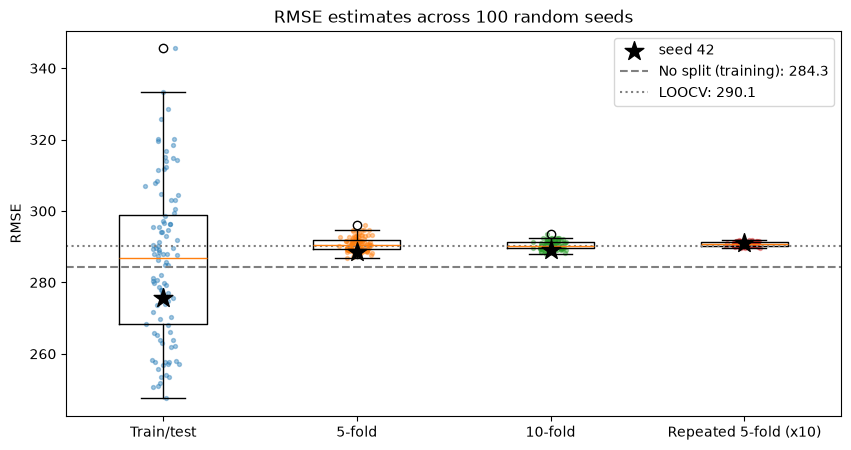

,mean,std,min,max
method,,,,
Train/test,285.7,21.6,247.5,345.5
5-fold,290.8,1.9,287.0,296.0
10-fold,290.4,1.1,288.1,293.5
Repeated 5-fold (x10),290.8,0.6,289.7,291.9


In [ ]:
# How much does each RMSE estimate change with the random seed?'
# This tells us how much the SPLIT impacts the answer we are seeing. 
# With a different dataset, we will get a different answer

def cv_rmse(method):
    mse = -cross_val_score(model, Xp, yp, cv=method, scoring="neg_mean_squared_error")
    return np.sqrt(mse.mean())

rows = []
for seed in range(100):
    X_train, X_test, y_train, y_test = train_test_split(Xp, yp, test_size=0.2, random_state=seed)
    model.fit(X_train, y_train)
    rows += [
        {"method": "Train/test", "seed": seed,
         "rmse": root_mean_squared_error(y_test, model.predict(X_test))},
        {"method": "5-fold", "seed": seed,
         "rmse": cv_rmse(KFold(n_splits=5, shuffle=True, random_state=seed))},
        {"method": "10-fold", "seed": seed,
         "rmse": cv_rmse(KFold(n_splits=10, shuffle=True, random_state=seed))},
        {"method": "Repeated 5-fold (x10)", "seed": seed,
         "rmse": cv_rmse(RepeatedKFold(n_splits=5, n_repeats=10, random_state=seed))},
    ]
by_seed = pd.DataFrame(rows)

# No split and LOOCV don't depend on the seed: one value each.
no_split = root_mean_squared_error(yp, model.fit(Xp, yp).predict(Xp))
loocv = cv_rmse(LeaveOneOut())

order = ["Train/test", "5-fold", "10-fold", "Repeated 5-fold (x10)"]
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([by_seed.loc[by_seed.method == m, "rmse"] for m in order], tick_labels=order)
for i, m in enumerate(order, start=1):
    vals = by_seed.loc[by_seed.method == m, "rmse"]
    ax.scatter(np.random.default_rng(0).normal(i, 0.04, len(vals)), vals, s=8, alpha=0.4)
    ax.scatter(i, by_seed.loc[(by_seed.method == m) & (by_seed.seed == 42), "rmse"],
               marker="*", s=200, color="black", zorder=3, label="seed 42" if i == 1 else None)
ax.axhline(no_split, color="gray", ls="--", label=f"No split (training): {no_split:.1f}")
ax.axhline(loocv, color="gray", ls=":", label=f"LOOCV: {loocv:.1f}")
ax.set(ylabel="RMSE", title="RMSE estimates across 100 random seeds")
ax.legend()
plt.show()

display(by_seed.groupby("method")["rmse"].agg(["mean", "std", "min", "max"]).loc[order].round(1))


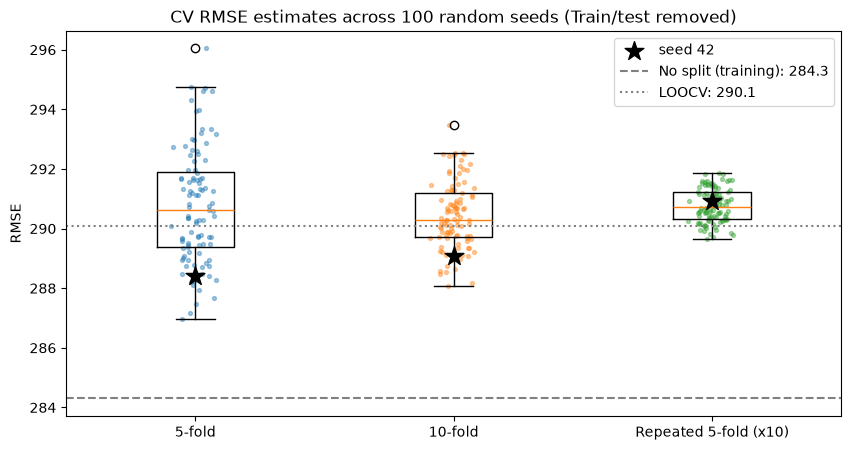

In [9]:
# Same comparison without Train/test, zoomed in on the CV methods.
order_cv = ["5-fold", "10-fold", "Repeated 5-fold (x10)"]
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([by_seed.loc[by_seed.method == m, "rmse"] for m in order_cv], tick_labels=order_cv)
for i, m in enumerate(order_cv, start=1):
    vals = by_seed.loc[by_seed.method == m, "rmse"]
    ax.scatter(np.random.default_rng(0).normal(i, 0.04, len(vals)), vals, s=8, alpha=0.4)
    ax.scatter(i, by_seed.loc[(by_seed.method == m) & (by_seed.seed == 42), "rmse"],
               marker="*", s=200, color="black", zorder=3, label="seed 42" if i == 1 else None)
ax.axhline(no_split, color="gray", ls="--", label=f"No split (training): {no_split:.1f}")
ax.axhline(loocv, color="gray", ls=":", label=f"LOOCV: {loocv:.1f}")
ax.set(ylabel="RMSE", title="CV RMSE estimates across 100 random seeds (Train/test removed)")
ax.legend()
plt.show()

## Data: bike rentals

In [10]:
bike = pd.read_csv("../data/bike-sharing-daily.csv")

cat = ["season", "weathersit", "mnth", "weekday", "yr", "holiday", "workingday"]
num = ["temp", "atemp", "hum", "windspeed"]
#num = ["temp", "hum", "windspeed"]

X = bike[cat + num]
y = bike["cnt"]

# One-hot encode the categorical columns as a preprocessing step.
preprocess = make_column_transformer(
    (OneHotEncoder(drop="first", sparse_output=False), cat),
    remainder="passthrough",
    verbose_feature_names_out=False,
)

# Creates a cross validator to split data into train/test splits
# Shuffle=True means that we are shuffling the data before selecting
# Setting a random state = reproducible output
cv = KFold(n_splits=5, shuffle=True, random_state=42)

## Part 2: Comparing Forward/Backward/RFE

In [ ]:
# Now let's build three pipelines and see what features are selected. 
forward = make_pipeline(
    preprocess, StandardScaler(),
    SequentialFeatureSelector(LinearRegression(), n_features_to_select=6,
                              direction="forward", cv=cv,
                              scoring="neg_root_mean_squared_error"),
    LinearRegression())
forward.fit(X, y)
print("Forward: ", list(forward[:-1].get_feature_names_out()))

backward = make_pipeline(
    preprocess, StandardScaler(),
    SequentialFeatureSelector(LinearRegression(), n_features_to_select=6,
                              direction="backward", cv=cv,
                              scoring="neg_root_mean_squared_error"),
    LinearRegression())
backward.fit(X, y)
print("Backward:", list(backward[:-1].get_feature_names_out()))

rfe = make_pipeline(preprocess, StandardScaler(),
                    RFE(LinearRegression(), n_features_to_select=6),
                    LinearRegression())
rfe.fit(X,y)
print("RFE:     ", list(rfe[:-1].get_feature_names_out()))

Forward:  ['season_2', 'season_4', 'weathersit_2', 'weathersit_3', 'yr_1', 'atemp']
Backward: ['season_2', 'season_4', 'yr_1', 'temp', 'hum', 'windspeed']
RFE:      ['season_2', 'season_3', 'season_4', 'yr_1', 'temp', 'atemp']


In [ ]:
# To understand things like: forward[:-1] we can look at the pipeline objects
# Pipeline is a class. It has both functions and attributes
# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
print(forward)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['season', 'weathersit',
                                                   'mnth', 'weekday', 'yr',
                                                   'holiday', 'workingday'])],
                                   verbose_feature_names_out=False)),
                ('standardscaler', StandardScaler()),
                ('sequentialfeatureselector',
                 SequentialFeatureSelector(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                                           estimator=LinearRegression(),
                                           n_features_to_select=6,
                                   

In [16]:
# Now we will write a function to summarize the outputs of different pipeline runs
def summarize(pipe, name):
    feats = pipe[:-1].get_feature_names_out()
    lr = pipe[-1] # This is the logistic regression step of the pipeline
    r2 = r2_score(y, pipe.predict(X))
    n, p = len(y), len(feats)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    coefs = pd.Series(lr.coef_, index=feats, name=name)
    return coefs, {"model": name, "R2": r2, "Adj R2": adj_r2, "intercept": lr.intercept_}

f_coefs, f_fit = summarize(forward, "forward")
b_coefs, b_fit = summarize(backward, "backward")
rfe_coefs, rfe_fit = summarize(rfe, "RFE")

# Coefficients side by side. NaN means that method didn't select the feature.
display(pd.concat([f_coefs, b_coefs, rfe_coefs], axis=1).round(3))
display(pd.DataFrame([f_fit, b_fit, rfe_fit]).set_index("model").round(4))

,forward,backward,RFE
season_2,248.571,292.214,465.073
season_4,497.537,528.209,618.418
weathersit_2,-292.357,NaN,NaN
weathersit_3,-384.556,NaN,NaN
yr_1,1013.524,990.278,1052.851
atemp,1183.761,NaN,554.816
temp,NaN,1244.296,416.288
hum,NaN,-403.390,NaN
windspeed,NaN,-302.999,NaN
season_3,NaN,NaN,390.393


,R2,Adj R2,intercept
model,,,
forward,0.7920,0.7903,4504.3488
backward,0.7909,0.7891,4504.3488
RFE,0.7500,0.7479,4504.3488


Remember: The way sklearn implements forward and backward selection is to do cross-validation at each step to decide which feature to drop. RFE without CV does not do this. It drops features based on the magnitude of the Linear Regression coefficients. So it is not surprising that it would have lower adjusted $R^2$

Note: The intercept is the same for each model because we have scaled the coefficients. The mean of each column is zero, and so the intercept is the mean value of y (average daily rental count) regardless of which features are selected.

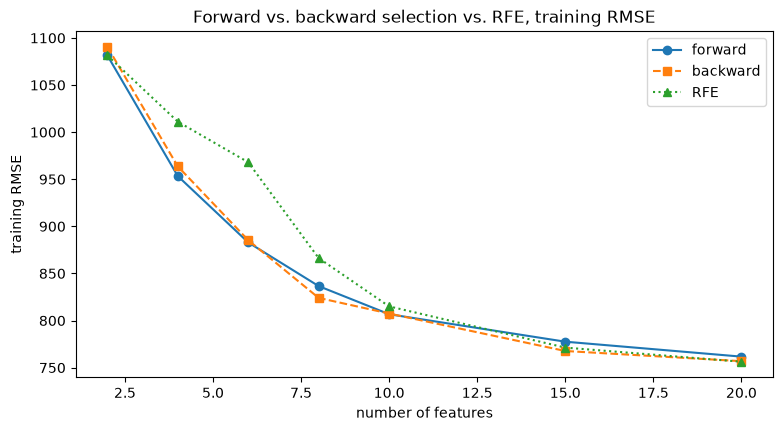

In [17]:
# Let's plot RMSE for different values of k
# We want to see how each method does for a different number of features. 
rows = []
for direction in ["forward", "backward", "RFE"]:
    for k in [2, 4, 6, 8, 10, 15, 20]:
        if direction == "RFE":
            selector = RFE(LinearRegression(), n_features_to_select=k)
        else:
            selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select=k,
                                                 direction=direction, cv=cv, n_jobs=-1,
                                                 scoring="neg_root_mean_squared_error")
        pipe = make_pipeline(preprocess, StandardScaler(), selector, LinearRegression()).fit(X, y)
        rows.append({"direction": direction, "k": k,
                     "train_rmse": root_mean_squared_error(y, pipe.predict(X))})
train_paths = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4.5))
for direction, style in [("forward", "o-"), ("backward", "s--"), ("RFE", "^:")]:
    d = train_paths[train_paths.direction == direction]
    ax.plot(d.k, d.train_rmse, style, label=direction)
ax.set(xlabel="number of features", ylabel="training RMSE",
       title="Forward vs. backward selection vs. RFE, training RMSE")
ax.legend()
plt.show()

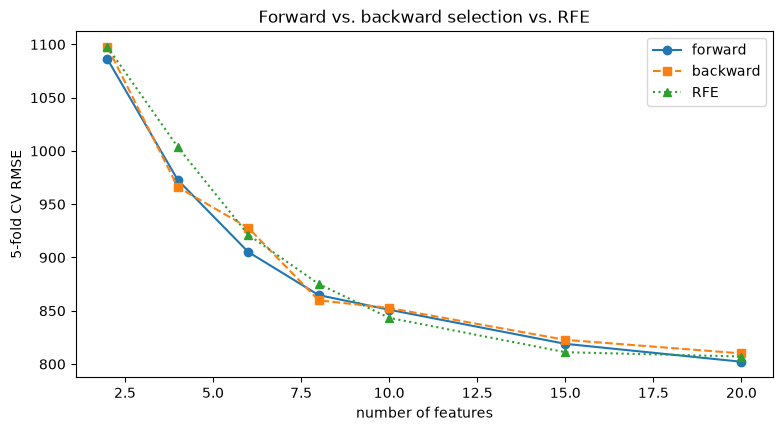

In [ ]:
# Now we will do cross validation to score the whole pipeline at different numbers of features.
# We are now using cross validation to score the whole selection process.
# In each fold, features are selected on training rows. 
# Slow: 1-2 minutes. n_jobs=-1 runs the 5 folds in parallel.
rows = []
for direction in ["forward", "backward", "RFE"]:
    for k in [2, 4, 6, 8, 10, 15, 20]:
        if direction == "RFE":
            selector = RFE(LinearRegression(), n_features_to_select=k)
        else:
            selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select=k,
                                                 direction=direction, cv=cv,
                                                 scoring="neg_root_mean_squared_error")
        pipe = make_pipeline(preprocess, StandardScaler(), selector, LinearRegression())
        # The next line splits the rows into 5 folds, fit the model on 4 folds, score on the 5th
        # Then repeat 5 times, and take the mean of the outputted array of scores
        score = -cross_val_score(pipe, X, y, cv=cv, n_jobs=-1,
                                 scoring="neg_root_mean_squared_error").mean()
        rows.append({"direction": direction, "k": k, "cv_rmse": score})
paths = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4.5))
for direction, style in [("forward", "o-"), ("backward", "s--"), ("RFE", "^:")]:
    d = paths[paths.direction == direction]
    ax.plot(d.k, d.cv_rmse, style, label=direction)
ax.set(xlabel="number of features", ylabel="5-fold CV RMSE",
       title="Forward vs. backward selection vs. RFE")
ax.legend()
plt.show()

In [21]:
# How much higher CV RMSE is than training RMSE (no outer CV), at each k.
merged = train_paths.merge(paths, on=["direction", "k"])
merged["cv_minus_train"] = merged.cv_rmse - merged.train_rmse
display(merged.pivot(index="k", columns="direction", values="cv_minus_train").round(1))

direction,RFE,backward,forward
k,,,
2,16.3,7.1,4.8
4,-7.4,2.4,19.4
6,-46.6,42.6,22.3
8,8.9,35.8,28.1
10,28.3,45.2,44.3
15,39.8,55.0,41.4
20,50.8,53.1,40.5


## Part 3: Backward selection vs. RFE vs. RFECV

In [23]:
start = time.perf_counter()
backward.fit(X, y)
print(f"Backward SFS: {time.perf_counter() - start:.3f} s")

rfe = make_pipeline(preprocess, StandardScaler(),
                    RFE(LinearRegression(), n_features_to_select=6),
                    LinearRegression())
start = time.perf_counter()
rfe.fit(X, y)
print(f"RFE:          {time.perf_counter() - start:.3f} s")

rfecv = make_pipeline(preprocess, StandardScaler(),
                      RFECV(LinearRegression(), cv=cv, scoring="neg_root_mean_squared_error"),
                      LinearRegression())
start = time.perf_counter()
rfecv.fit(X, y)
print(f"RFECV:        {time.perf_counter() - start:.3f} s")

Backward SFS: 1.243 s
RFE:          0.010 s
RFECV:        0.060 s


In [24]:
print("Backward SFS:", list(backward[:-1].get_feature_names_out()))
print("RFE:         ", list(rfe[:-1].get_feature_names_out()))
print(f"RFECV kept {rfecv[2].n_features_} features:", list(rfecv[:-1].get_feature_names_out()))

Backward SFS: ['season_2', 'season_4', 'yr_1', 'temp', 'hum', 'windspeed']
RFE:          ['season_2', 'season_3', 'season_4', 'yr_1', 'temp', 'atemp']
RFECV kept 28 features: ['season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'yr_1', 'holiday_1', 'workingday_1', 'temp', 'atemp', 'hum', 'windspeed']


In [25]:
# Using the function from previously. 
b_coefs, b_fit = summarize(backward, "backward")
rfe_coefs, rfe_fit = summarize(rfe, "rfe")
rfecv_coefs, rfecv_fit = summarize(rfecv, "rfecv")

# Coefficients side by side. NaN means that method didn't select the feature.
display(pd.concat([b_coefs, rfe_coefs, rfecv_coefs], axis=1).round(3))
display(pd.DataFrame([b_fit, rfe_fit, rfecv_fit]).set_index("model").round(4))

,backward,rfe,rfecv
season_2,292.214,465.073,386.949
season_4,528.209,618.418,678.451
yr_1,990.278,1052.851,1009.597
temp,1244.296,416.288,528.011
hum,-403.390,NaN,-219.121
windspeed,-302.999,NaN,-218.843
season_3,NaN,390.393,369.400
atemp,NaN,554.816,289.510
weathersit_2,NaN,NaN,-218.514
weathersit_3,NaN,NaN,-328.080


,R2,Adj R2,intercept
model,,,
backward,0.7909,0.7891,4504.3488
rfe,0.7500,0.7479,4504.3488
rfecv,0.8484,0.8423,4504.3488


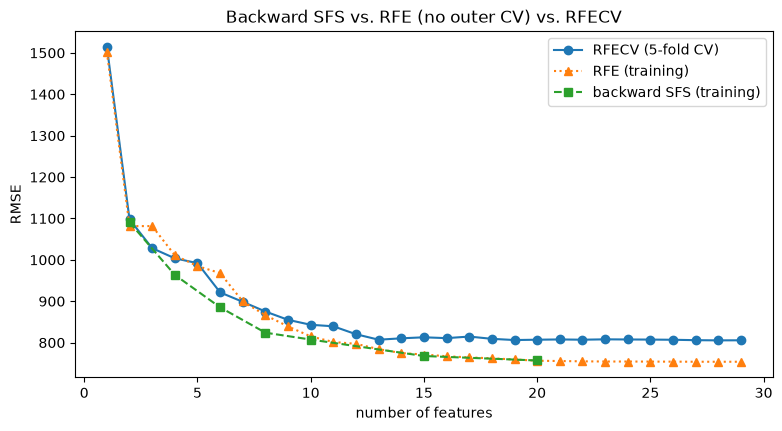

In [ ]:
# As we did before, let's look at training RMSE (no outer CV) of the three pipelines at different values of k.

# We can grab the rfecv results from our run earlier
results = rfecv[2].cv_results_

# We need to run RFE again because earlier we didn't save the results at every k
rfe_train = [root_mean_squared_error(
                 y, make_pipeline(preprocess, StandardScaler(),
                                  RFE(LinearRegression(), n_features_to_select=k),
                                  LinearRegression()).fit(X, y).predict(X))
             for k in results["n_features"]]

# Backward SFS training RMSE was computed previously so we don't need to recompute.
bwd_train = train_paths[train_paths.direction == "backward"]

plt.figure(figsize=(9, 4.5))
plt.plot(results["n_features"], -results["mean_test_score"], "o-", label="RFECV (5-fold CV)")
plt.plot(results["n_features"], rfe_train, "^:", label="RFE (training)")
plt.plot(bwd_train.k, bwd_train.train_rmse, "s--", label="backward SFS (training)")
plt.xlabel("number of features")
plt.ylabel("RMSE")
plt.title("Backward SFS vs. RFE (no outer CV) vs. RFECV")
plt.legend()
plt.show()

In [32]:
# As with before, we can interrogate the pipeline to understand what we are getting out of it
# https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFECV.html
print(rfecv)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['season', 'weathersit',
                                                   'mnth', 'weekday', 'yr',
                                                   'holiday', 'workingday'])],
                                   verbose_feature_names_out=False)),
                ('standardscaler', StandardScaler()),
                ('rfecv',
                 RFECV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=LinearRegression(),
                       scoring='neg_root_mean_squared_error')),
                ('linearregression', LinearRegression())])


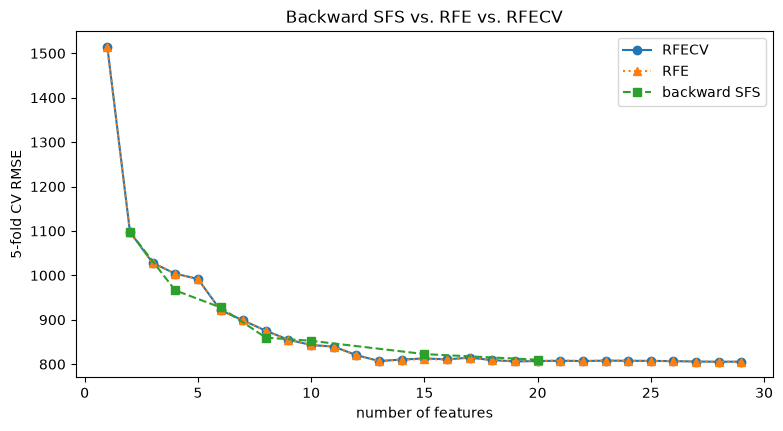

In [33]:
# Now we are going to do what we did previously and instead of scoring on train RMSE we do cv

# Can just grab this again from RFECV
results = rfecv[2].cv_results_

# CV RMSE of the RFE pipeline at every size. 
rfe_rmse = [-cross_val_score(make_pipeline(preprocess, StandardScaler(),
                                           RFE(LinearRegression(), n_features_to_select=k),
                                           LinearRegression()),
                             X, y, cv=cv, scoring="neg_root_mean_squared_error").mean()
            for k in results["n_features"]]

# Backward SFS scores with CV were computed previously so we can just grab them.
bwd = paths[paths.direction == "backward"]

plt.figure(figsize=(9, 4.5))
plt.plot(results["n_features"], -results["mean_test_score"], "o-", label="RFECV")
plt.plot(results["n_features"], rfe_rmse, "^:", label="RFE")
plt.plot(bwd.k, bwd.cv_rmse, "s--", label="backward SFS")
plt.xlabel("number of features")
plt.ylabel("5-fold CV RMSE")
plt.title("Backward SFS vs. RFE vs. RFECV")
plt.legend()
plt.show()

What is the difference between RFE using the cross_val_score and RFECV? 

RFE only works with a specified number of features. If we put a pipeline with RFE into cross_val_score, as we have done above, each fold will run RFE down to the fixed number of features, and score the held out rows. 

RFECV scores every k each time, using the same folds. Then, it picks the k with the lowest cross validated RMSE, and refits RFE on all data to that size. So it helps you pick which k is the best. 

Both methods do the same thing at each fold, which is why there is so much overlap in the plots above. 

## Parts 1 and 2 again: with vs. without atemp

`temp` and `atemp` ("feels like" temperature) are almost perfectly correlated and RFE chooses them both. We are now going to REMOVE atemp from our set of colums and repeat every selection method with and without `atemp` to see what removing a multicollinear predictor up front does.

A few notes: A lot of the code below is repeated from above, and wrapped into a function. This is closer to how you would typically try to write this in a .py file vs a notebook. 

In [34]:
def run_parts_1_2(num):
    """Parts 1 and 2 for predictors cat + num: fit each selection method at 6 features
    (RFECV picks its own size), then CV-score each method at several sizes."""
    X = bike[cat + num]
    pre = make_column_transformer(
        (OneHotEncoder(drop="first", sparse_output=False), cat),
        remainder="passthrough", verbose_feature_names_out=False)

    def selector(method, k):
        if method == "RFE":
            return RFE(LinearRegression(), n_features_to_select=k)
        return SequentialFeatureSelector(LinearRegression(), n_features_to_select=k,
                                         direction=method, cv=cv,
                                         scoring="neg_root_mean_squared_error")

    selectors = {m: selector(m, 6) for m in ["forward", "backward", "RFE"]}
    selectors["RFECV"] = RFECV(LinearRegression(), cv=cv, scoring="neg_root_mean_squared_error")
    pipes = {m: make_pipeline(pre, StandardScaler(), s, LinearRegression()).fit(X, y)
             for m, s in selectors.items()}

    # Coefficients and in-sample R2 / Adj R2 of each selected model.
    coefs, fits = {}, []
    for m, pipe in pipes.items():
        feats = pipe[:-1].get_feature_names_out()
        r2 = r2_score(y, pipe.predict(X))
        n, p = len(y), len(feats)
        coefs[m] = pd.Series(pipe[-1].coef_, index=feats)
        fits.append({"model": m, "n_features": p, "R2": r2,
                     "Adj R2": 1 - (1 - r2) * (n - 1) / (n - p - 1)})

    # CV RMSE of the whole pipeline (selection included) at several sizes.
    rows = []
    for m in ["forward", "backward", "RFE"]:
        for k in [2, 4, 6, 8, 10, 15, 20]:
            pipe = make_pipeline(pre, StandardScaler(), selector(m, k), LinearRegression())
            score = -cross_val_score(pipe, X, y, cv=cv, n_jobs=-1,
                                     scoring="neg_root_mean_squared_error").mean()
            rows.append({"method": m, "k": k, "cv_rmse": score})
    res = pipes["RFECV"][2].cv_results_
    rows += [{"method": "RFECV", "k": k, "cv_rmse": -s}
             for k, s in zip(res["n_features"], res["mean_test_score"])]

    return {"pipes": pipes,
            "coefs": pd.DataFrame(coefs),
            "fits": pd.DataFrame(fits).set_index("model"),
            "paths": pd.DataFrame(rows)}

In [35]:
# Slow: runs everything twice
with_atemp = run_parts_1_2(["temp", "atemp", "hum", "windspeed"])
without_atemp = run_parts_1_2(["temp", "hum", "windspeed"])

In [38]:
for label, r in [("With atemp", with_atemp), ("Without atemp", without_atemp)]:
    print(label)
    for method, pipe in r["pipes"].items():
        feats = list(pipe[:-1].get_feature_names_out())
        n = f" ({len(feats)} features)" if method == "RFECV" else ""
        print(f"  {method:9s}{n}", feats)
        #print(f"  {method:9s}", list(pipe[:-1].get_feature_names_out()))

With atemp
  forward   ['season_2', 'season_4', 'weathersit_2', 'weathersit_3', 'yr_1', 'atemp']
  backward  ['season_2', 'season_4', 'yr_1', 'temp', 'hum', 'windspeed']
  RFE       ['season_2', 'season_3', 'season_4', 'yr_1', 'temp', 'atemp']
  RFECV     (28 features) ['season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'yr_1', 'holiday_1', 'workingday_1', 'temp', 'atemp', 'hum', 'windspeed']
Without atemp
  forward   ['season_2', 'season_4', 'weathersit_2', 'weathersit_3', 'yr_1', 'temp']
  backward  ['season_2', 'season_4', 'yr_1', 'temp', 'hum', 'windspeed']
  RFE       ['season_2', 'season_3', 'season_4', 'weathersit_3', 'yr_1', 'temp']
  RFECV     (13 features) ['season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'mnth_9', 'mnth_10', 'weekday_6', 'yr_1', 'workingday_1', 

In [39]:
# Coefficients side by side. NaN means that method didn't select the feature.
#display(pd.concat({"with atemp": with_atemp["coefs"],
#                   "without atemp": without_atemp["coefs"]}, axis=1).round(1))
display(pd.concat({"with atemp": with_atemp["fits"],
                   "without atemp": without_atemp["fits"]}, axis=1).round(4))

with atemp                 without atemp                
         n_features      R2  Adj R2    n_features      R2  Adj R2
model                                                            
forward           6  0.7920  0.7903             6  0.7954  0.7937
backward          6  0.7909  0.7891             6  0.7909  0.7891
RFE               6  0.7500  0.7479             6  0.7835  0.7817
RFECV            28  0.8484  0.8423            13  0.8397  0.8368

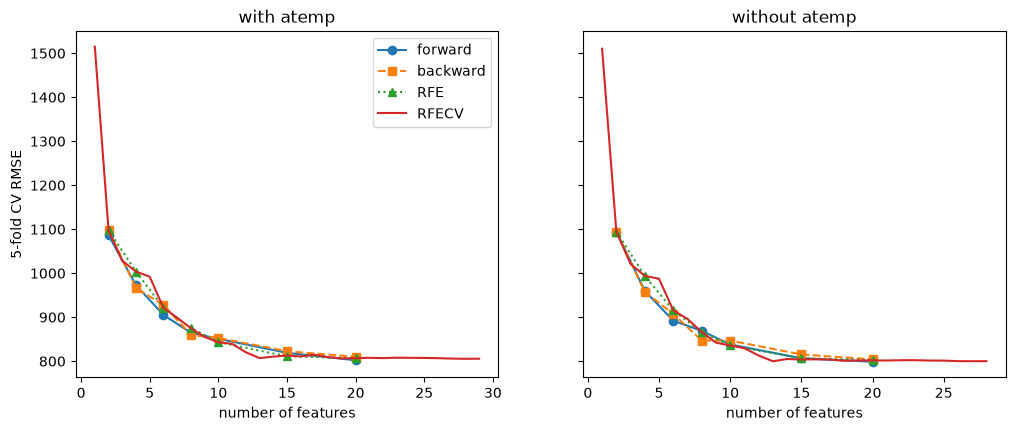

In [40]:
# CV RMSE vs. number of features, with and without atemp, on the same y-axis.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (label, r) in zip(axes, [("with atemp", with_atemp), ("without atemp", without_atemp)]):
    for method, style in [("forward", "o-"), ("backward", "s--"), ("RFE", "^:"), ("RFECV", "-")]:
        d = r["paths"][r["paths"].method == method]
        ax.plot(d.k, d.cv_rmse, style, label=method)
    ax.set(title=label, xlabel="number of features")
axes[0].set_ylabel("5-fold CV RMSE")
axes[0].legend()
plt.show()